Zad.1  
Klasyfikacja gatunków kosaćca (Iris dataset)  
Treść: Wykonaj klasyfikację gatunków kosaćca na podstawie cech morfologicznych.  
Dodatkowo: Sprawdź, jak zmieniają się metryki klasyfikacji w zaleźności od liczby drzew w lesie (n_estimators)

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = load_iris()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [3]:
model1 = DecisionTreeClassifier(random_state=42)
model2 = RandomForestClassifier(random_state=42)
model1.fit(X_train, y_train)
model2.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)

In [4]:
print("Classification report for Decision Tree: \n", classification_report(y_test, y_pred1))
print("Confusion matrix for Decision Tree: \n", confusion_matrix(y_test, y_pred1))
print("Classification report for Random Forest: \n", classification_report(y_test, y_pred2))
print("Confusion matrix for Random Forest: \n", confusion_matrix(y_test, y_pred2))

Classification report for Decision Tree: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion matrix for Decision Tree: 
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification report for Random Forest: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      1.00      0.95         9
           2       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Confusion matrix for Random Forest: 
 [[10  0  0]
 [ 0  9  0]
 [ 0  1 10]]


In [5]:
cm1 = confusion_matrix(y_test, y_pred1)
cm2 = confusion_matrix(y_test, y_pred2)

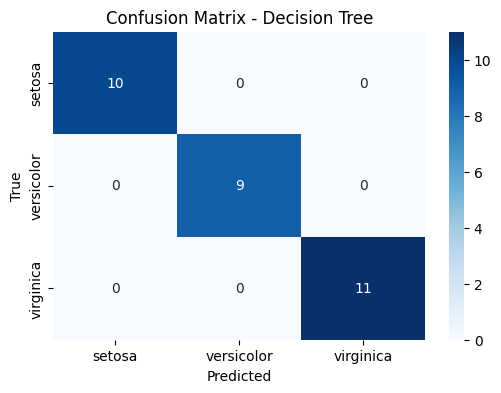

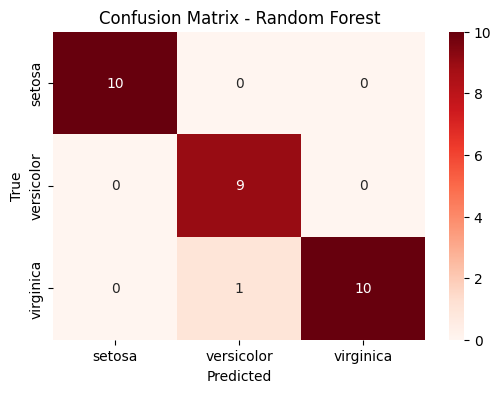

In [6]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm1, annot=True, cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Decision Tree')
plt.show()
plt.figure(figsize=(6, 4))
sns.heatmap(cm2, annot=True, cmap='Reds', xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Random Forest')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

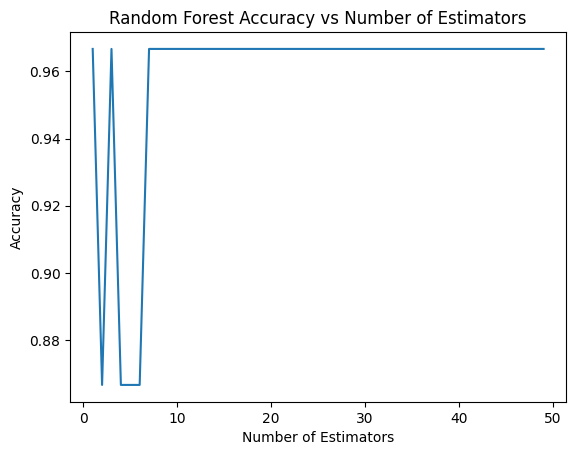

In [7]:
estimators_range = range(1, 50, 1)
scores = []

for n in estimators_range:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    scores.append(report['accuracy'])

plt.plot(estimators_range, scores)
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy vs Number of Estimators')
plt.show

Zad.2  
Wykrywanie cukrzycy (Diabetes dataset)  
Treść: Dokonaj klasyfikacja obecności cukrzycy.  
Dodatkowo: Porównaj skuteczność modelu w zależności od maksymalnej głębokości drzewa (max_depth).

In [8]:
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

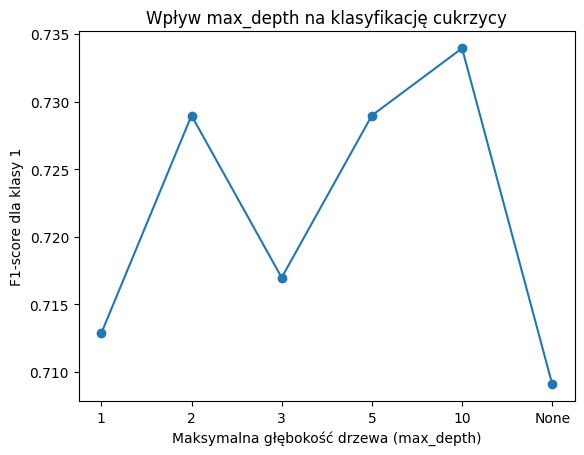

In [9]:
X, y = load_diabetes(return_X_y=True)
y = (y > y.mean()).astype(int) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

depths = [1, 2, 3, 5, 10, None]
f1_scores = []

for d in depths:
    model = RandomForestClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    f1_scores.append(report['1']['f1-score'])

plt.plot([str(d) for d in depths], f1_scores, marker='o')
plt.xlabel('Maksymalna głębokość drzewa (max_depth)')
plt.ylabel('F1-score dla klasy 1')
plt.title('Wpływ max_depth na klasyfikację cukrzycy')
plt.show()

Zad.3  
Rozpoznawanie cyfr (Digits dataset)  
Treść: Wykonaj klasyfikację cyfr odręcznych (0–9) za pomocą algorytmu drzewa decyzyjnego i lasu losowego.  
Dodatkowo: Wykonaj badanie algorytmów w zależności od wybranego parametru np. sprawdź, jak zmienia się skuteczność klasyfikacji w zależności od liczby cech losowanych przy każdym podziale (max_features).

In [10]:
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

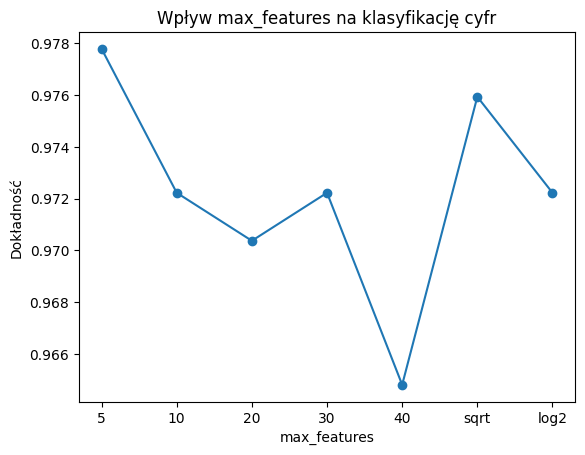

In [11]:
X, y = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

features_range = [5, 10, 20, 30, 40, 'sqrt', 'log2']
accuracies = []

for f in features_range:
    model = RandomForestClassifier(max_features=f, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    accuracies.append(report['accuracy'])

plt.plot([str(f) for f in features_range], accuracies, marker='o')
plt.xlabel('max_features')
plt.ylabel('Dokładność')
plt.title('Wpływ max_features na klasyfikację cyfr')
plt.show()

Zad.4  
Klasyfikacja nowotworów piersi (Breast Cancer Wisconsin dataset)  
Cel: Zbuduj klasyfikator rozpoznający, czy guz piersi jest złośliwy czy łagodny, na podstawie cech diagnostycznych za pomocą algorytmu drzewa decyzyjnego i lasu losowego.  
Dodatkowo: Wykonaj badanie algorytmów w zależności od wybranego parametru np. zbadaj, jak wpływa parametr criterion (gini vs entropy) na jakość klasyfikacji (metryki: precision, recall, F1-score).

In [12]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

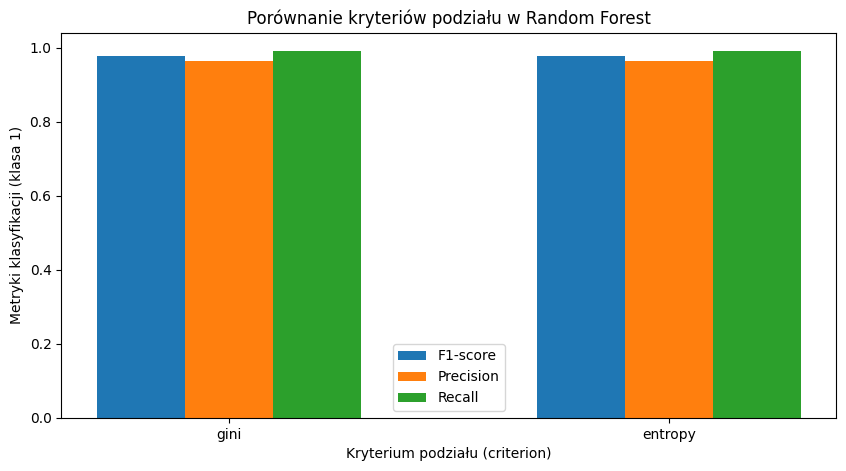

In [13]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

criteria = ['gini', 'entropy']
f1_scores = []
precision_scores = []
recall_scores = []

for c in criteria:
    model = RandomForestClassifier(criterion=c, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    f1_scores.append(report['1']['f1-score'])
    precision_scores.append(report['1']['precision'])
    recall_scores.append(report['1']['recall'])

x = range(len(criteria))
plt.figure(figsize=(10, 5))
plt.bar(x, f1_scores, width=0.2, label='F1-score', align='center')
plt.bar([i + 0.2 for i in x], precision_scores, width=0.2, label='Precision', align='center')
plt.bar([i + 0.4 for i in x], recall_scores, width=0.2, label='Recall', align='center')
plt.xticks([i + 0.2 for i in x], criteria)
plt.xlabel('Kryterium podziału (criterion)')
plt.ylabel('Metryki klasyfikacji (klasa 1)')
plt.title('Porównanie kryteriów podziału w Random Forest')
plt.legend()
plt.show()